#  Wine classification model using k-NN (k-Nearest Neighbors)

#### Author 1
- **Name:** João Pedro Fernandes de Aquino
- **GitHub:** https://github.com/Joaof14

#### Author 2
- **Name:** Anderson Carlos da Silva Morais
- **GitHub:** https://github.com/AndersonCSM

## Project Summary

The wine industry has historically relied on human assessments—expensive, slow, and subjective. A predictive quality model has direct applications in batch control before bottling, pricing, and designation of origin certification by regulatory bodies. In oenological research (the science that studies the production, preservation, and analysis of wines), it also helps identify which chemical variables most influence the perception of quality, guiding production decisions. Platforms like Vivino (https://www.vivino.com/BR/pt-BR/) already use machine learning for this purpose. In Brazil, the context of the São Francisco Valley—the world's largest tropical wine hub, located here in the Northeast—makes the problem especially relevant and motivating for our reality. In this project, you are invited to build a wine classification model into three quality categories (low, medium, and high) from a set of chemical data using k-NN (k-Nearest Neighbors).



## Project Steps
1. Data exploration and quality checks;
2. Validate modeling assumptions;
3. Feature selection;
4. Normalization or scaling and Data split;
5. Model fitting (adjustment);
6. Assessment;
7. Coefficient or feature-importance analysis;
8. Residual/error analysis;
9.  Report.

## Step 1: Data Exploration and Quality Checks
#### Collecting evidence about the dataset before making modeling decisions.

The project uses the winequality-red.csv file from the [Wine Quality dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality). The dataset was created by Paulo Cortez et al. (University of Minho, Portugal) and published in 2009. It includes 1,599 samples of red wine from the Vinho Verde region in northwest Portugal. Each sample was subjected to laboratory tests that generated 11 physicochemical attributes — such as fixed acidity, volatile acidity, citric acid content, residual sugar, chlorides, sulfur dioxide, density, pH, sulfates, and alcohol content. The quality label is an integer value from 0 to 10 assigned by sommeliers in blind evaluations, representing the median of at least three human evaluations.

For more information, read [Cortez et al., 2009].
Input variables (based on physicochemical tests):
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
   10. sulphates
   11. alcohol

Output variable (based on sensory data): 

   12. quality (score between 0 and 10)


Steps:

1. **Initial Inspection**
   * `df.info()`: check the number of rows and columns, and the data types (int, float, object).
   * `df.describe()`: obtain a quick statistical summary (mean, standard deviation, minimum, maximum, and quartiles).

2. **Data Quality Validation**
   * **Missing Values:** check whether missing data exist (`df.isnull().sum()`) and define a strategy (input using median for 'ca' and 'thal').
   * **Duplicate Data:** identify and remove identical readings that may distort the analysis (`df.duplicated().sum()`).
   * **Target Variable** Binarize the target variable: transform original values (0-4) to binary (0 = no disease, 1 = with disease);

3. **Univariate Analysis**
   * **Distribution:** plot histograms to understand how each sensor's data is distributed.
   * **Outlier Detection:** use boxplots to identify extreme values that deviate from the expected plant pattern.

4. **Bivariate and Multivariate Analysis**
   * **Correlation Matrix:** compute indices such as Pearson's correlation to quantify the strength of the relationship between variables.
   * **Visual Trends:** create box plots crossing the predictor variables with the target variable to validate hypotheses visually.For categorical predictors, stacked bar charts are used to show the proportion of the target across each category



In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,
)

In [3]:
df = pd.read_csv("data/p03_winequality-red.csv", sep=";")

In [4]:
print(f"Dataset shape: {df.shape}")
print(f"\nFirst rows of the dataset:")
df.head(10)

Dataset shape: (1599, 12)

First rows of the dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


### 1.0 Initial inspection

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

### 1.1 Separation into classes

In [7]:
df["target"] = pd.cut(
df["quality"],
bins=[0, 5, 7, 10],
labels=[0, 1, 2], # - O ruim, 1 - médio, 2 - bom
include_lowest=True
).astype(int)

df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'target'],
      dtype='str')

In [8]:
df = df.drop(columns=["quality"])
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='str')

In [9]:
X = df.drop(columns=["target"])
y = df["target"]

### 1.2 Balanceamento de Classes (Crítico para KNN)

Se a quantidade de amostras de grupo não for balanceada, um grupo pode sobrepor os demais para classificar as amostras.

In [10]:
# Verificar balanceamento do target
print("Balanceamento de classes (target):")
print(df["target"].value_counts().sort_index())
print("\nProporção (%):")
print(df["target"].value_counts(normalize=True).sort_index() * 100)

Balanceamento de classes (target):
target
0    744
1    837
2     18
Name: count, dtype: int64

Proporção (%):
target
0    46.529081
1    52.345216
2     1.125704
Name: proportion, dtype: float64


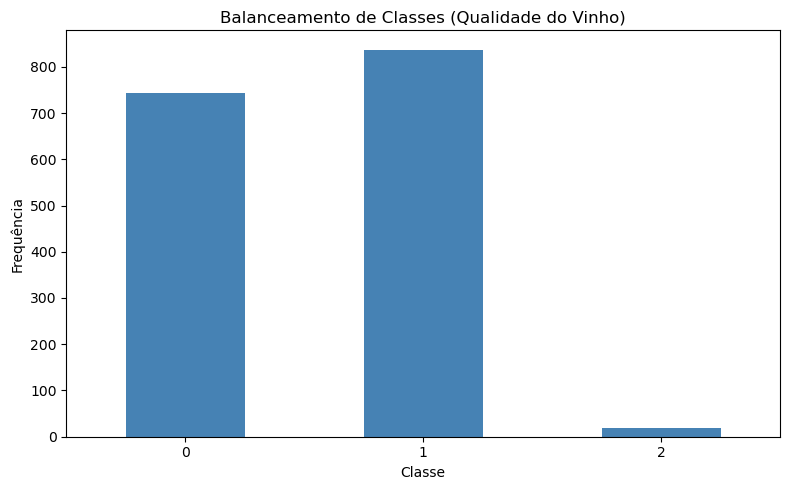

In [11]:
# Visualizar distribuição
fig, ax = plt.subplots(figsize=(8, 5))
df["target"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Balanceamento de Classes (Qualidade do Vinho)", fontsize=12)
ax.set_xlabel("Classe")
ax.set_ylabel("Frequência")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 1.3 Escala das Variáveis

Etapa essencial para auxiliar no processo de normalização. pois diferentes escalas entre variáveis -> Normalização OBRIGATÓRIA para KNN

Total de features numéricas: 11
Colunas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


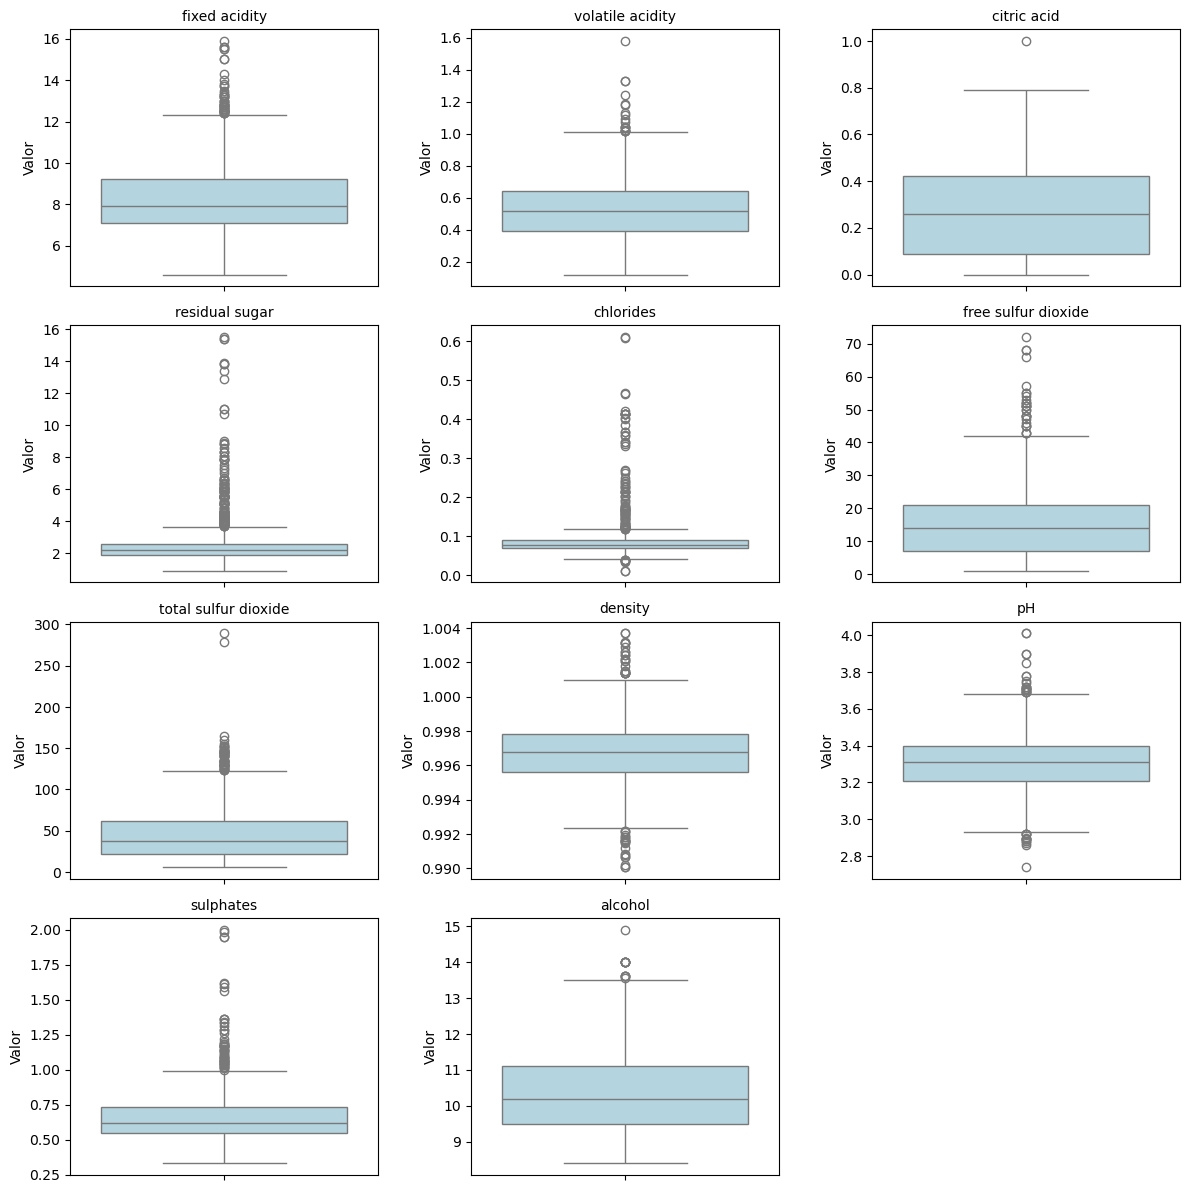

In [12]:
# Listar todas as colunas numéricas (excluindo quality e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["quality", "target"]]

print(f"Total de features numéricas: {len(numeric_cols)}")
print(f"Colunas: {numeric_cols}")

# Boxplots para ver escala - KNN é sensível a escala (grade dinâmica)
ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_ylabel("Valor")

# Remover subplots não utilizados
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 1.4 Detecção de Outliers (Afetam Distância no KNN)
 Outliers podem dominar distâncias -> Considere normalizar ou usar métrica ponderada

obs:
IQR = Interquartile Range (Amplitude Interquartil)

É a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1):

In [13]:
# Função para quantificar outliers usando IQR
def count_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), (lower, upper)

print("Quantificação de Outliers (IQR 1.5x):\n")
outlier_summary = []
for col in numeric_cols:
    count, (lower, upper) = count_outliers_iqr(df, col)
    pct = (count / len(df)) * 100
    outlier_summary.append({"Feature": col, "Outliers": count, "Percentual": f"{pct:.2f}%"})
    print(f"{col:20s}: {count:3d} outliers ({pct:.2f}%)")

df_outliers = pd.DataFrame(outlier_summary)

Quantificação de Outliers (IQR 1.5x):

fixed acidity       :  49 outliers (3.06%)
volatile acidity    :  19 outliers (1.19%)
citric acid         :   1 outliers (0.06%)
residual sugar      : 155 outliers (9.69%)
chlorides           : 112 outliers (7.00%)
free sulfur dioxide :  30 outliers (1.88%)
total sulfur dioxide:  55 outliers (3.44%)
density             :  45 outliers (2.81%)
pH                  :  35 outliers (2.19%)
sulphates           :  59 outliers (3.69%)
alcohol             :  13 outliers (0.81%)


### 1.5 Matriz de Correlação

Objetivo: detectar redundância nas features.

Correlação de cada feature com o target (qualidade):

alcohol                 0.450986
sulphates               0.223183
citric acid             0.165994
fixed acidity           0.094288
residual sugar         -0.001474
pH                     -0.009287
free sulfur dioxide    -0.064615
chlorides              -0.113781
density                -0.170227
total sulfur dioxide   -0.231076
volatile acidity       -0.320968
Name: target, dtype: float64


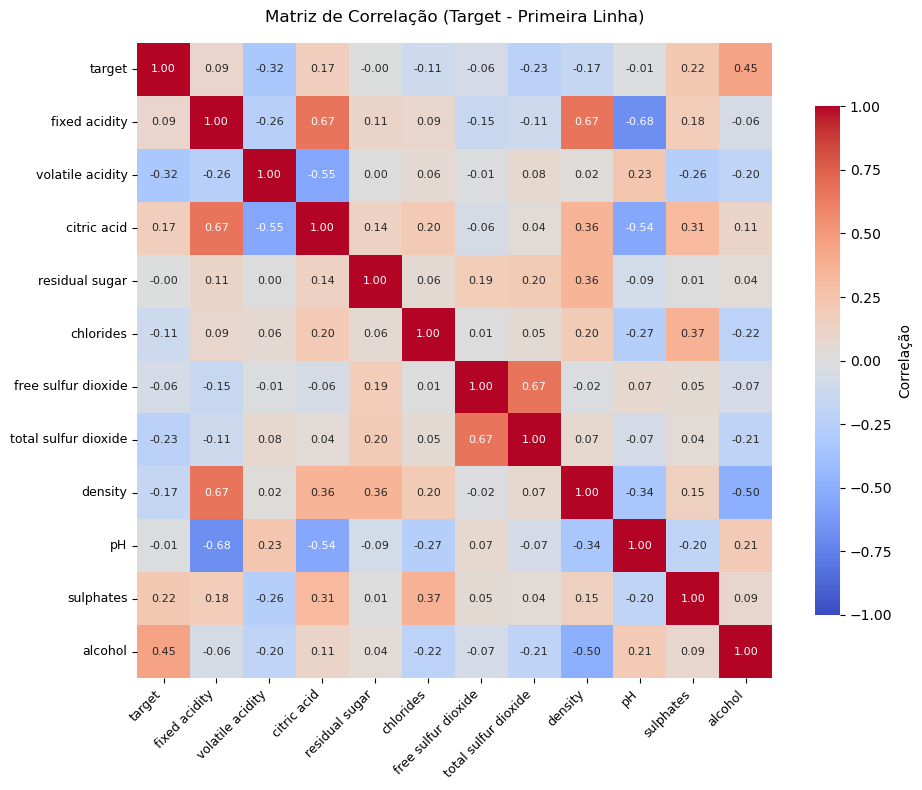

  Nenhuma redundância detectada (correlação > 0.7)


In [14]:
# Calcular correlação com o target
corr_matrix = df[numeric_cols + ["target"]].corr()

# Extrair a linha target nas colunas numeric_cols (garante Series)
corr_with_target = corr_matrix.loc["target", numeric_cols]

# Ordenar
corr_with_target = corr_with_target.sort_values(ascending=False)

print("Correlação de cada feature com o target (qualidade):\n")
print(corr_with_target)

# Heatmap com target na primeira linha - Versão minimalista
# Reordenar: target primeiro, depois as demais colunas
cols_reordered = ["target"] + numeric_cols
corr_matrix = corr_matrix.reindex(cols_reordered)[cols_reordered]

fig, ax = plt.subplots(figsize=(10, 8))

# Minimalista: sem bordas, sem elementos visuais desnecessários
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            center=0, 
            linewidths=0,
            vmin=-1, 
            vmax=1, 
            ax=ax,
            cbar_kws={"label": "Correlação", "shrink": 0.8},
            square=True,
            annot_kws={"size": 8})

ax.set_title("Matriz de Correlação (Target - Primeira Linha)", fontsize=12, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# Detectar features muito correlacionadas (redundância)
high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr_val = corr_matrix.iloc[i+1, j+1]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((numeric_cols[i], numeric_cols[j], corr_val))
            print(f"  {numeric_cols[i]:20s} <-> {numeric_cols[j]:20s}: {corr_val:.3f}")

if not high_corr_pairs:
    print("  Nenhuma redundância detectada (correlação > 0.7)")

### 1.6 Visual Trends - Distribuição por Classe (Separabilidade para KNN)

Top 6 features com maior correlação com qualidade:
alcohol                 0.450986
volatile acidity       -0.320968
total sulfur dioxide   -0.231076
sulphates               0.223183
density                -0.170227
citric acid             0.165994
Name: target, dtype: float64


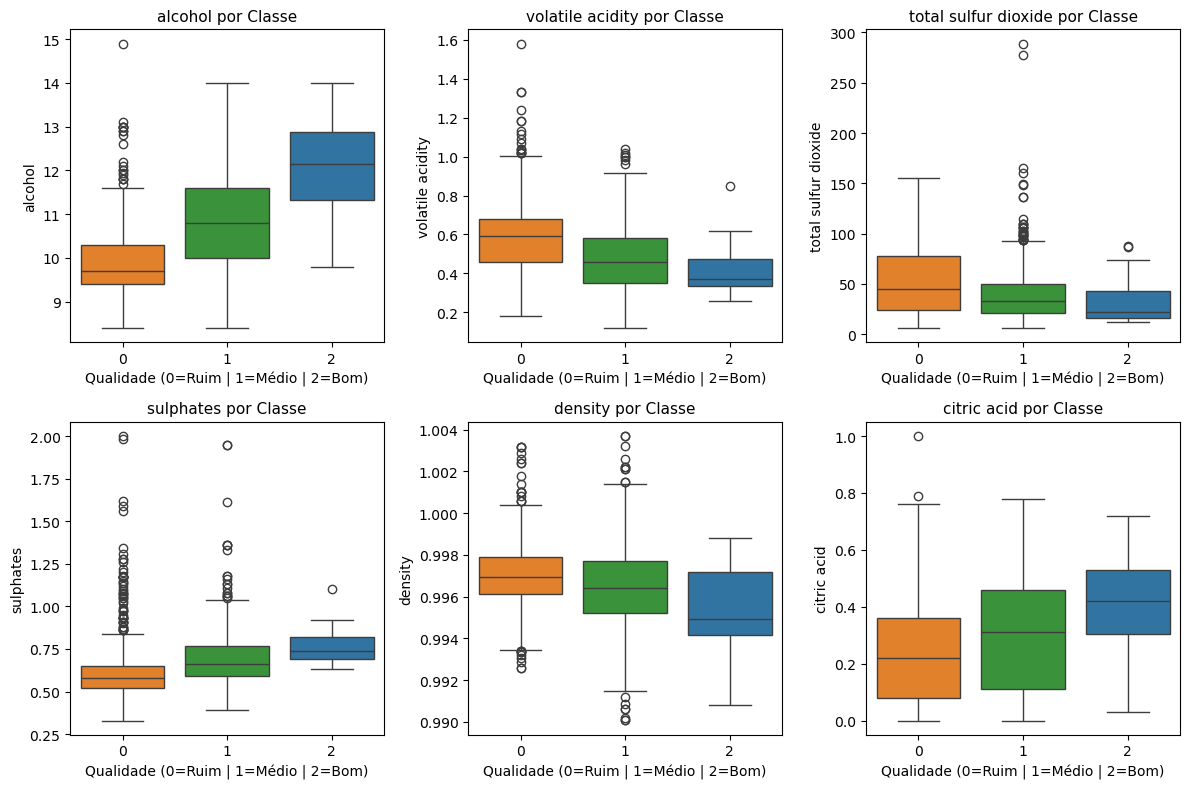


✓ Se há boa separação entre boxplots, KNN terá melhor desempenho


In [15]:
# Selecionar features com maior correlação com o target para visualização
top_features = corr_with_target.abs().nlargest(6).index.tolist()

print(f"Top 6 features com maior correlação com qualidade:")
print(corr_with_target[top_features])

# Boxplots cruzados
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Palette com valores em string (seaborn espera string quando x é categórico)
palette = {"0": "#ff7f0e", "1": "#2ca02c", "2": "#1f77b4"}

for i, feat in enumerate(top_features):
    # Converter target para string para compatibilidade com paleta
    sns.boxplot(x=df["target"].astype(str), y=df[feat], ax=axes[i], palette=palette)
    axes[i].set_title(f"{feat} por Classe", fontsize=11)
    axes[i].set_xlabel("Qualidade (0=Ruim | 1=Médio | 2=Bom)")
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.show()

print("\n✓ Se há boa separação entre boxplots, KNN terá melhor desempenho")

### 1.7 Resumo data explorer
1. BALANCEAMENTO DE CLASSES:

   Ruim: 46.5% | Médio: 52.3% | Bom: 1.1%
   Classes desbalanceadas -> utilizar stratify no train_test_split

2. ESCALA DAS VARIÁVEIS:

   11 features numéricas com escalas diferentes
   NORMALIZAÇÃO OBRIGATÓRIA -> StandardScaler ou MinMaxScaler

3. OUTLIERS:

   Total: 573 outliers em 11 features
   Percentual médio: 3.26%
   Outliers significativos -> normalizar reduz impacto

4. REDUNDÂNCIA DE FEATURES:

   Nenhuma redundância detectada

5. TOP 3 FEATURES MAIS CORRELACIONADAS COM QUALIDADE:
   1. alcohol: 0.451
   2. sulphates: 0.223
   3. citric acid: 0.166

6. PRÓXIMOS PASSOS:
   1. Normalizar features (StandardScaler)
   2. Dividir treino/teste com stratify
   3. Testar k=1,3,5,7,11... com validação cruzada
   4. Escolher melhor k por acurácia média
   5. Avaliar no conjunto teste (matriz confusão, F1-score)

## Step 2: Validar Premissas do Modelo k‑NN (Validate Modeling Assumptions for k‑NN)

Interpretamos as evidências da Etapa 1 e decidimos se o modelo k‑NN é adequado para este problema.

### 2.1 Natureza do modelo
- **k‑NN é um algoritmo não paramétrico baseado em instâncias.** Ele não assume linearidade, normalidade nem homocedasticidade. Portanto, muitas premissas clássicas de regressão não se aplicam.

### 2.2 Requisitos principais para o k‑NN

| Requisito | Status | Evidência da Etapa 1 | Decisão |
|-----------|--------|----------------------|----------|
| **Normalização** | Obrigatória | As features têm escalas muito diferentes (ex.: `alcohol` ~8‑15, `density` ~0,99‑1,00, `residual sugar` ~0‑15).  Sem normalização, variáveis de maior escala dominariam a distância euclidiana. | **Aplicar `MinMaxScaler()` ou `StandardScaler`(z-score)**. |
| **Balanceamento das classes** | Crítico para o vizinho mais próximo | Distribuição das classes: 0 (ruim): 46,5%, 1 (médio): 52,3%, 2 (bom): 1,1%. Desbalanceamento severo para a classe 2. | **Usar divisão estratificada** para preservar as proporções. Possivelmente aplicar pesos ou reamostragem se o desempenho da classe minoritária for ruim. |
| **Sensibilidade a outliers** | Alta | Os boxplots confirmaram outliers em features como `residual sugar` (9,7%), `chlorides` (7,0%), `total sulfur dioxide` (3,4%). | **A normalização reduz o domínio dos outliers.** Escalonamento robusto (`RobustScaler`) pode ser testado como alternativa. |
| **Métrica de distância** | Distância euclidiana sensível à escala e a atributos irrelevantes | A matriz de correlação não mostra multicolinearidade extrema (> 0,7). Nenhum atributo é redundante. | **Manter todas as features**; a distância euclidiana é aceitável após normalização. |
| **Separabilidade não linear** | k‑NN consegue capturar fronteiras complexas | Os boxplots por classe mostram que as classes se sobrepõem em algumas variáveis (ex.: `fixed acidity`, `pH`), mas são melhor separadas em outras (`alcohol`, `volatile acidity`). | O k‑NN é adequado; ele pode aprender fronteiras de decisão locais sem assumir separabilidade linear. |

### 2.3 Avaliação geral
- **O k‑NN é apropriado** para este problema, desde que:
  1. Todas as variáveis numéricas sejam normalizadas.
  2. Seja usada uma divisão estratificada treino/teste para lidar com o desbalanceamento das classes.
  3. Os outliers não sejam removidos, mas sua influência seja mitigada pelo escalonamento.
- **Nenhuma transformação adicional** (log, Box‑Cox) é necessária, pois o k‑NN é robusto a distribuições assimétricas após a normalização.

### 2.4 Próximos passos
- A normalização deve ser feita após a divisão treino/teste, ajustando o scaler apenas no treino e transformando treino e teste.
- **A validação cruzada** (5‑folds) no conjunto de treino será usada para selecionar o melhor `k`.
- **As métricas de avaliação** incluirão acurácia, precisão, recall e F1‑score por classe, com atenção especial à classe minoritária (bom).

=========================================================================================

Interpret the evidence from Step 1 and decide whether the k‑NN model is appropriate for this problem.

### 2.1 Nature of the model
- **k‑NN is a non‑parametric, instance‑based algorithm.** It does not assume linearity, normality, or homoscedasticity. Therefore, many classical regression assumptions do not apply.

### 2.2 Key requirements for k‑NN

| Requirement | Status | Evidence from Step 1 | Decision |
|-------------|--------|----------------------|----------|
| **Normalization** | Mandatory | Features have very different scales (e.g., `alcohol` ~8‑15, `density` ~0.99‑1.00, `residual sugar` ~0‑15). Without normalization, larger‑scale features would dominate Euclidean distance. | **Will apply `MinMaxScaler` or `StandardScaler`(z-score) **. |
| **Class balance** | Critical for nearest neighbor | Class distribution: 0 (ruim): 46.5%, 1 (médio): 52.3%, 2 (bom): 1.1%. Severe imbalance for class 2. | **Use stratified split** to preserve proportions. May consider class weights or resampling if performance for minority class is poor. |
| **Outlier sensitivity** | High | Boxplots confirmed outliers in features like `residual sugar` (9.7%), `chlorides` (7.0%), `total sulfur dioxide` (3.4%). | **Normalization reduces dominance of outliers.** Robust scaling (`RobustScaler`) can be tested as an alternative. |
| **Distance metric** | Euclidean distance sensitive to scale and irrelevant features | Correlation matrix shows no extreme multicollinearity (> 0.7). No feature is redundant. | **Keep all features**; Euclidean distance is acceptable after normalization. |
| **Non‑linear separability** | k‑NN can capture complex boundaries | Boxplots by class show that classes overlap in some features (e.g., `fixed acidity`, `pH`) but are better separated in others (`alcohol`, `volatile acidity`). | k‑NN is suitable; it can learn local decision boundaries without assuming linear separability. |

### 2.3 Overall assessment
- **k‑NN is appropriate** for this problem, provided that:
  1. All numerical features are normalized.
  2. Stratified train/test split is used to handle class imbalance.
  3. Outliers are not removed but their influence is mitigated by scaling.
- **No further transformations** (log, Box‑Cox) are required, as k‑NN is robust to skewed distributions after scaling.

### 2.4 Next steps
- Normalization will be performed in Step 4 after the data train-test split, fitting the scaler only on the training set and transforming both training and test sets.
- **Cross‑validation** (5‑fold) on the training set will be used to select the best `k`.
- **Evaluation metrics** will include accuracy, precision, recall, and F1‑score per class, with special attention to the minority class (bom).

## Step 3: Seleção de variáveis (Feature Selection)

Com base na matriz de correlação (Step 1), nenhum par de variáveis apresentou correlação superior a 0,7, indicando ausência de multicolinearidade severa. Portanto, todas as 11 variáveis físico‑químicas serão mantidas para o treinamento do modelo.


=============================================================================================================================================

Based on Step 1 (the correlation matrix), no pair of variables showed a correlation higher than 0.7, indicating the absence of severe multicollinearity. Therefore, all 11 physicochemical variables will be retained for model training.


## Step 4 and 5: Normalização e Divisão treino-teste (Normalization and Data Split)

***Observação***

["A abordagem recomendada consiste em normalizar os dados após os dividir em conjuntos de treino e de teste. A razão por trás desta recomendação é evitar qualquer fuga de informação do conjunto de teste para o conjunto de treino, o que pode levar a resultados excessivamente otimistas e avaliações de desempenho irrealistas."](https://medium.com/@spinjosovsky/normalize-data-before-or-after-split-of-training-and-testing-data-7b8005f81e26)

***Notes***

["The recommended approach is to normalize the data after splitting it into training and testing sets. The rationale behind this recommendation is to prevent any information leakage from the testing set into the training set, which can lead to over-optimistic results and unrealistic performance evaluations."](https://medium.com/@spinjosovsky/normalize-data-before-or-after-split-of-training-and-testing-data-7b8005f81e26)

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Separar X e y (se ainda não tiver feito)
X = df.drop(columns=['target'])
y = df['target']

# Inicializar o scaler para normalizar em z-score
scaler = MinMaxScaler()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Divisão estratificada primeiro
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Depois normaliza com base APENAS no treino
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 6: Treinamento dos Modelos (Model Fitting)


k =  1 -> Acurácia média (CV): 0.7162
k =  3 -> Acurácia média (CV): 0.6864
k =  5 -> Acurácia média (CV): 0.6990
k =  7 -> Acurácia média (CV): 0.6912
k = 11 -> Acurácia média (CV): 0.7107

Melhor k: 1


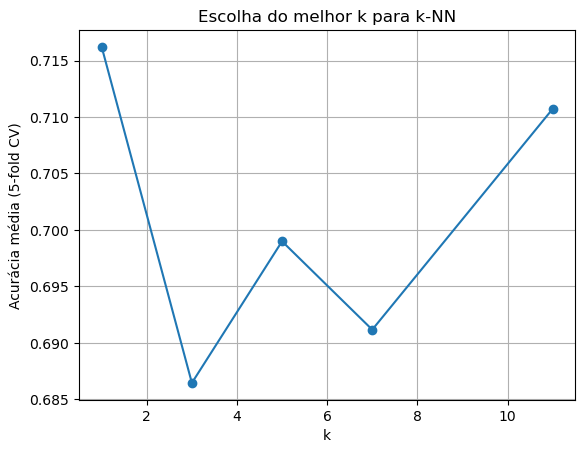

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 11]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Exibir resultados
for k, score in zip(k_values, cv_scores):
    print(f"k = {k:2d} -> Acurácia média (CV): {score:.4f}")

# Escolher o melhor k
best_k = k_values[np.argmax(cv_scores)]
print(f"\nMelhor k: {best_k}")

# Plotar
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Acurácia média (5-fold CV)')
plt.title('Escolha do melhor k para k-NN')
plt.grid(True)
plt.show()

***Observações***
- Valores muito baixos de k (ex.: k = 1): O modelo se torna muito flexível e complexo, aprendendo detalhes específicos e até ruído dos dados de treino. Isso causa overfitting: alta variância, baixa capacidade de generalização. Pequenas variações nos dados de treino podem alterar drasticamente as previsões. No nosso caso, k=1 apresentou a maior acurácia média na validação cruzada, mas é importante verificar se esse desempenho se mantém no teste.

- Valores muito altos de k (ex.: k = 11): O modelo se torna mais simples e suave, considerando muitos vizinhos para decidir a classe. Isso reduz a influência de ruído, mas pode levar a underfitting, onde o modelo não captura padrões importantes dos dados. A fronteira de decisão fica muito genérica, e a acurácia tende a cair. No nosso caso, k=11 teve acurácia (0.7107) próxima a k=1, mas ligeiramente inferior.

- Escolha final: Apesar de k=1 ter sido o melhor na validação cruzada, ele é o mais propenso a overfitting. Decidimos testar também k=3 e k=5 para verificar se no conjunto de teste há diferença significativa. Em problemas com classes desbalanceadas, k pequeno pode favorecer a classe majoritária, como observado na avaliação posterior.

***Notes***
- Very low k (e.g., k = 1): The model becomes highly flexible and complex, learning specific details and even noise from the training data. This leads to overfitting: high variance and poor generalization. Small changes in the training data can drastically change predictions. In our case, k=1 achieved the highest CV accuracy, but we must check if this performance holds on the test set.

- Very high k (e.g., k = 11): The model becomes simpler and smoother, considering many neighbors to decide the class. This reduces the impact of noise but can cause underfitting, where the model fails to capture important patterns. The decision boundary becomes too generic, and accuracy tends to drop. Here, k=11 had accuracy (0.7107) close to k=1 but slightly lower.

- Final choice: Although k=1 was the best in cross‑validation, it is the most prone to overfitting. We also test k=3 and k=5 to see if there is a significant difference on the test set. In problems with imbalanced classes, small k may favor the majority class, as observed in the later evaluation.

## Step 7: Assessment

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Treinar o modelo final com o melhor k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(cm)

# Relatório por classe
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=['ruim', 'médio', 'bom']))

# Acurácia geral
accuracy = knn_final.score(X_test_scaled, y_test)
print(f"\nAcurácia no teste: {accuracy:.4f}")

Matriz de confusão:
[[113  36   0]
 [ 45 122   0]
 [  1   2   1]]

Relatório de classificação:
              precision    recall  f1-score   support

        ruim       0.71      0.76      0.73       149
       médio       0.76      0.73      0.75       167
         bom       1.00      0.25      0.40         4

    accuracy                           0.74       320
   macro avg       0.82      0.58      0.63       320
weighted avg       0.74      0.74      0.74       320


Acurácia no teste: 0.7375


***Observações***

- O modelo tem desempenho razoável para as classes majoritárias (ruim e médio), com F1‑score em torno de 0,74.
- Há confusão bilateral significativa entre ruim e médio, indicando que as características químicas dessas duas categorias são similares.
- A classe bom apenas tem apenas amostras no teste e apresenta recall muito baixo, ou seja, o modelo falha em identificar vinhos de alta qualidade, classificando‑os majoritariamente como médio. A precisão de 100% é enganosa.
- Os resultados no teste (73,75%) estão alinhados com a validação cruzada (71,6% para k=1), sugerindo ausência de overfitting severo.

***Notes***
- The model performs reasonably well for the majority classes (Bad and Medium), with F1‑scores around 0.74.
- There is significant bidirectional confusion between Bad and Medium, indicating that the chemical features of these two categories are similar.
- The Good class (minority, only 4 test samples) shows very low recall; the model fails to identify high‑quality wines, mostly classifying them as Medium. The 100% precision is misleading (only one correct prediction).
- Test accuracy aligns with cross‑validation, suggesting no severe overfitting.

## Step 8: Analise de Importância de Feature (Feature‑Importance Analysis)

Diferentemente de modelos lineares ou baseados em árvores, o **k‑NN não produz coeficientes** diretamente, pois é um algoritmo baseado em distância. A importância de cada variável pode ser inferida por:

1. **Correlação com a variável alvo** (já apresentada na Etapa 1):  
   As três variáveis com maior correlação absoluta com a qualidade foram:
   - `alcohol` (+0,45) – maior teor alcoólico associado a vinhos de melhor qualidade.
   - `volatile acidity` (-0,32) – acidez volátil elevada prejudica a qualidade.
   - `sulphates` (+0,22) – sulfatos contribuem positivamente para a percepção de qualidade.

2. **Análise de separabilidade por classe (Step 1)**:  
   Os boxplots mostraram que `alcohol`, `volatile acidity` e `total sulfur dioxide` apresentam boa separação entre as classes, indicando sua relevância para a discriminação.

3. **Métrica de distância ponderada**:  
   O k‑NN padrão usa distância euclidiana, que já atribui peso implícito baseado na escala das variáveis. Como normalizamos os dados com `MinMaxScaler`, todas as variáveis contribuem igualmente para o cálculo da distância.

**Conclusão:** As variáveis mais importantes para o modelo são aquelas com maior correlação com a qualidade, especialmente `alcohol`, `volatile acidity` e `sulphates`. O comportamento do modelo é consistente com o conhecimento enológico: maior teor alcoólico e sulfatos indicam vinhos de qualidade superior, enquanto acidez volátil elevada está associada a vinhos de qualidade inferior.

=============================================================================================================================================

Unlike linear or tree‑based models, **k‑NN does not produce coefficients** directly, as it is a distance‑based algorithm. Feature importance can be inferred from:

1. **Correlation with the target variable** (already presented in Step 1):  
   The three features with the highest absolute correlation with quality were:
   - `alcohol` (+0.45) – higher alcohol content associated with better wine quality.
   - `volatile acidity` (-0.32) – high volatile acidity impairs quality.
   - `sulphates` (+0.22) – sulphates contribute positively to quality perception.

2. **Class separability analysis (Step 1)**:  
   Boxplots showed that `alcohol`, `volatile acidity`, and `total sulfur dioxide` exhibit good separation between classes, indicating their relevance for discrimination.

3. **Weighted distance metric**:  
   Standard k‑NN uses Euclidean distance, which implicitly assigns weight based on feature scale. Since we normalized the data with `MinMaxScaler`, all features contribute equally to distance calculations.

**Conclusion:** The most important features for the model are those with the highest correlation with quality, especially `alcohol`, `volatile acidity`, and `sulphates`. The model’s behavior aligns with oenological knowledge: higher alcohol and sulphate levels indicate higher‑quality wines, while high volatile acidity is linked to lower quality.


## Step 9: Análise de Erros na CLassificação (Residual/Error Analysis - Classification)

Conjunto de teste: **320 amostras**  
Total de erros: **320 - 236 = 84 erros** (taxa de erro ≈ 26,25%)

### Distribuição dos erros por classe real

| Classe real | Amostras | Erros | % erro na classe | Principal confusão |
|-------------|----------|-------|------------------|--------------------|
| Ruim (0)    | 149      | 36    | 24,2%            | Classificados como Médio |
| Médio (1)   | 167      | 45    | 26,9%            | Classificados como Ruim |
| Bom (2)     | 4        | 3     | 75,0%            | Classificados como Médio (2) e Ruim (1) |

### Padrões observados nos erros

1. **Erros concentrados na fronteira entre Ruim e Médio**:  
   As classes Ruim e Médio representam a grande maioria dos erros (81 dos 84 erros totais). Isso indica que as características químicas dessas duas categorias são muito próximas, tornando difícil a separação perfeita.

2. **Classe Bom é muito rara**:  
   Com apenas 4 amostras no teste, o modelo não teve exemplos suficientes para aprender um padrão consistente. Os três erros mostram que o modelo tende a classificar vinhos de alta qualidade como Médio (a classe majoritária mais próxima).

3. **Possíveis causas dos erros**:
   - **Desbalanceamento severo** – a classe Bom representa apenas 1,1% do total.
   - **Sobreposição natural** dos atributos químicos entre vinhos ruins e médios.
   - **k=1 pode amplificar ruído** – embora a acurácia geral seja razoável, o modelo pode estar capturando variações locais que não generalizam bem.

### Sugestões de melhoria

- Aplicar técnicas de **balanceamento** (SMOTE, pesos nas classes, ou oversampling da classe Bom).
- Testar **k maior** (ex.: 3 ou 5) para suavizar decisões e reduzir overfitting.
- Coletar mais amostras da classe Bom, se possível.

=============================================================================================================================================

Test set: **320 samples**  
Total errors: **320 - 236 = 84 errors** (error rate ≈ 26.25%)

### Error distribution by true class

| True class | Samples | Errors | % error in class | Main confusion |
|------------|---------|--------|------------------|----------------|
| Bad (0)    | 149     | 36     | 24.2%            | Classified as Medium |
| Medium (1) | 167     | 45     | 26.9%            | Classified as Bad |
| Good (2)   | 4       | 3      | 75.0%            | Classified as Medium (2) and Bad (1) |

### Observed error patterns

1. **Errors concentrated at the Bad‑Medium boundary**:  
   Bad and Medium classes account for most errors (81 out of 84). This indicates that the chemical characteristics of these two categories are very close, making perfect separation difficult.

2. **Good class is extremely rare**:  
   With only 4 test samples, the model did not have enough examples to learn a consistent pattern. The three errors show that the model tends to classify high‑quality wines as Medium (the nearest majority class).

3. **Possible causes of errors**:
   - **Severe class imbalance** – Good class represents only 1.1% of the total.
   - **Natural overlap** of chemical attributes between Bad and Medium wines.
   - **k=1 may amplify noise** – while overall accuracy is reasonable, the model may be capturing local variations that do not generalize well.

### Improvement suggestions

- Apply **resampling techniques** (SMOTE, class weights, or oversampling of the Good class).
- Try **larger k** (e.g., 3 or 5) to smooth decisions and reduce overfitting.
- Collect more samples of the Good class, if possible.



In [20]:
# Identificar índices das amostras erradas
import numpy as np
errors = (y_pred != y_test)
X_test_errors = X_test[errors]
y_test_errors = y_test[errors]
y_pred_errors = y_pred[errors]

# Exibir algumas estatísticas descritivas
print("Média das features nos erros (por classe real):")
for class_val in [0, 1, 2]:
    mask = y_test_errors == class_val
    if mask.sum() > 0:
        print(f"Classe {class_val}: {mask.sum()} erros")

Média das features nos erros (por classe real):
Classe 0: 36 erros
Classe 1: 45 erros
Classe 2: 3 erros


## Step 10: Report




1. **Preparação dos dados:** carregue o dataset e recodifique a variável quality em três classes: notas ≤ 5 como
ruim, 6–7 como médio e ≥ 8 como bom. Em seguida, normalize todos os atributos utilizando Min-Max ou
Z-score. Justifique por que a normalização é uma etapa obrigatória para o 𝑘-NN. ***Variavel Quality: Realizado no step 1.1; Normalização: Step 4 e Step 5; Justificativa: O k‑NN calcula distâncias entre os ponto, logo se as variáveis estiverem em escalas diferentes as de maior magnitude dominariam a distância, distorcendo a busca pelos vizinhos mais próximos.***

2. **Divisão treino/teste:** divida os dados em 80% para treino e 20% para teste, utilizando divisão estratificada
para garantir que a proporção das três classes seja mantida em ambos os conjuntos. ***Realizado no step 4 e step 5*** 

3. **Treinamento e escolha do 𝑘:** treine o modelo para diferentes valores de 𝑘 (ex: 1, 3, 5, 7, 11) utilizando
validação cruzada de 5 folds sobre o conjunto de treino. Plote a acurácia média em função de 𝑘 e escolha
o valor com melhor desempenho. O que acontece com o modelo para valores muito baixos e muito altos
de 𝑘? ***Para valores muito baixos de k, como k igual a 1, o modelo se ajusta excessivamente aos dados de treino, capturando ruído e pontos isolados, o que caracteriza sobreajuste (overfitting); apesar de ter apresentado a maior acurácia média na validação cruzada (71,62%), esse modelo pode ter alta variância e generalizar mal para dados novos. Já para valores muito altos de k, como k igual a 11, o modelo se torna muito suave e genérico, considerando muitos vizinhos para decidir a classe, o que pode levar a subajuste (underfitting), onde a fronteira de decisão é simplificada demais e padrões relevantes são perdidos; a acurácia cai ligeiramente para 71,07%. O melhor valor de k foi 1, mas é recomendável verificar o desempenho no conjunto de teste; se houver indícios de overfitting, valores como k igual a 3 ou 5 podem ser mais adequados por equilibrarem viés e variância.***

4. **Avaliação do modelo:** utilizando o conjunto de teste — reservado exclusivamente para esta etapa — calcule
a matriz de confusão e as métricas de acurácia, precisão, recall e F1-score para cada classe. Responda:
Entre quais classes o modelo erra com mais frequência? ***O modelo erra principalmente entre as classes Ruim e Médio, confundindo‑as bilateralmente. A classe Bom também é mal classificada (apenas 1 acerto em 4), mas o número de amostras é muito pequeno para conclusões robustas.***